# VisualPromptCodec: Turning a Real Image into a Visual Prompt

This notebook walks through an end-to-end RGB visual-prompt optimization experiment.

We start from a real image, `images/burj.png`, then optimize its RGB pixels so a frozen multimodal Gemma model responds as if it had received this text prompt:

```text
explain AI as a caveman in one sentence
```

The model is never trained. Only the RGB image changes.

## 1. Conceptual Map

```text
Text branch:
  text prompt -> Gemma -> target hidden states / logits / answer tokens

Image branch:
  Burj RGB image + learnable perturbation -> Gemma -> predicted answer

Optimization:
  update only RGB pixels
  Gemma stays frozen
```

The key comparison at the end is:

```text
seed image output       -> should describe the Burj image
optimized image output  -> should answer the text prompt
random image output     -> should fail / describe noise
```

In [1]:
# 2. Environment check
from pathlib import Path
import json
import math
import platform
from datetime import datetime

import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
from IPython.display import display
from transformers import AutoProcessor, AutoModelForMultimodalLM

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

MODEL_PATH = ROOT / "models" / "gemma-4-E2B-it"
SEED_IMAGE_PATH = ROOT / "images" / "burj.png"
RUN_ROOT = ROOT / "outputs" / "notebook_runs"
RUN_ROOT.mkdir(parents=True, exist_ok=True)

print(f"Python: {platform.python_version()}")
print(f"Torch: {torch.__version__}")
try:
    import transformers
    print(f"Transformers: {transformers.__version__}")
except Exception as exc:
    print(f"Transformers version unavailable: {exc}")
print(f"MPS available: {torch.backends.mps.is_available() if hasattr(torch.backends, 'mps') else False}")
print(f"Model path exists: {MODEL_PATH.exists()} -> {MODEL_PATH}")
print(f"Seed image exists: {SEED_IMAGE_PATH.exists()} -> {SEED_IMAGE_PATH}")

Python: 3.14.4
Torch: 2.12.0
Transformers: 5.8.1
MPS available: True
Model path exists: True -> /Users/noufal/Documents/vscode/VisualPromptCodec/models/gemma-4-E2B-it
Seed image exists: True -> /Users/noufal/Documents/vscode/VisualPromptCodec/images/burj.png


## 3. Experiment Settings

These settings are intentionally small and readable. The tested run used 100 steps and usually finishes in a few minutes on Apple MPS.

In [2]:
PROMPT = "explain AI as a caveman in one sentence"
WRAPPER = "Respond:"
LAYERS = [16, 20, 24]
PRIMARY_LAYER = 20
PRIMARY_WEIGHT = 2.0

IMAGE_HEIGHT = 448
IMAGE_WIDTH = 448
STEPS = 100
LR = 0.01
LOG_EVERY = 10

LOGIT_KL_WEIGHT = 0.5
TARGET_CE_WEIGHT = 5.0
TARGET_MAX_NEW_TOKENS = 64
L2_WEIGHT = 0.02
TV_WEIGHT = 0.001
NOISE_SCALE = 0.01

RUN_DIR = RUN_ROOT / datetime.now().strftime("%Y%m%d_%H%M%S_burj_rgb")
RUN_DIR.mkdir(parents=True, exist_ok=False)

print(f"Prompt: {PROMPT}")
print(f"Wrapper: {WRAPPER!r}")
print(f"Layers: {LAYERS}")
print(f"Run directory: {RUN_DIR}")

Prompt: explain AI as a caveman in one sentence
Wrapper: 'Respond:'
Layers: [16, 20, 24]
Run directory: /Users/noufal/Documents/vscode/VisualPromptCodec/outputs/notebook_runs/20260520_142446_burj_rgb


In [3]:
# 4. Load Gemma and freeze it
processor = AutoProcessor.from_pretrained(MODEL_PATH)
model = AutoModelForMultimodalLM.from_pretrained(MODEL_PATH, dtype="auto", device_map="auto")
model.eval()
for p in model.parameters():
    p.requires_grad_(False)

device = next(model.parameters()).device
trainable_model_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model device: {device}")
print(f"Model dtype: {next(model.parameters()).dtype}")
print(f"Trainable Gemma parameters: {trainable_model_params}")

Loading weights:   0%|          | 0/1951 [00:00<?, ?it/s]

Model device: mps:0
Model dtype: torch.bfloat16
Trainable Gemma parameters: 0


## 5. Gemma Image Processor: The Important Shapes

We optimize RGB pixels, but Gemma internally consumes flattened image patches:

```text
RGB image [1, 3, 448, 448]
  -> resize to 768 x 768
  -> split into 16 x 16 RGB patches
  -> flatten each patch to 768 values
  -> pad to 2520 rows
  -> pixel_values [1, 2520, 768]
```

In [4]:
# 6. Helper functions: chat formatting, RGB preprocessing, losses, and display helpers
def apply_chat_template(messages):
    return processor.apply_chat_template(
        messages,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
        add_generation_prompt=True,
        enable_thinking=False,
    )

def move_batch(batch, device):
    return {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in batch.items()}

def build_text_inputs(prompt):
    return apply_chat_template([
        {"role": "system", "content": "You are a helpful assistant."},
        {"role": "user", "content": prompt},
    ])

def build_visual_inputs(image, wrapper=WRAPPER):
    content = [{"type": "image", "image": image}]
    if wrapper:
        content.append({"type": "text", "text": wrapper})
    return apply_chat_template([{"role": "user", "content": content}])

def pil_to_rgb_tensor(path, height=448, width=448, noise_scale=0.0, device=None):
    if device is None:
        device = next(model.parameters()).device
    image = Image.open(path).convert("RGB")
    resized = image.resize((width, height), resample=Image.Resampling.BICUBIC)
    arr = np.asarray(resized).astype("float32") / 255.0
    rgb = torch.from_numpy(arr).permute(2, 0, 1).unsqueeze(0).to(device)
    if noise_scale > 0:
        rgb = rgb + torch.randn_like(rgb) * noise_scale
    return rgb.clamp(0.0, 1.0), image, resized

def rgb_to_pil(rgb):
    img = rgb.detach().float().cpu().clamp(0, 1)[0].permute(1, 2, 0).numpy()
    return Image.fromarray((img * 255).round().astype("uint8"), mode="RGB")

def gemma_target_size(height, width, patch_size=16, max_soft_tokens=280, pooling_kernel_size=3):
    max_patches = max_soft_tokens * pooling_kernel_size ** 2
    target_pixels = max_patches * patch_size ** 2
    factor = math.sqrt(target_pixels / (height * width))
    side_multiple = pooling_kernel_size * patch_size
    target_height = int(math.floor((height * factor) / side_multiple)) * side_multiple
    target_width = int(math.floor((width * factor) / side_multiple)) * side_multiple
    return target_height, target_width

def patchify_rgb(rgb, patch_size=16):
    b, c, h, w = rgb.shape
    ph, pw = h // patch_size, w // patch_size
    patches = rgb.reshape(b, c, ph, patch_size, pw, patch_size)
    patches = patches.permute(0, 2, 4, 3, 5, 1)
    return patches.reshape(b, ph * pw, patch_size * patch_size * c)

def image_position_ids_for_grid(batch_size, patch_height, patch_width, max_patches, device):
    x_grid, y_grid = torch.meshgrid(torch.arange(patch_width, device=device), torch.arange(patch_height, device=device), indexing="xy")
    positions = torch.stack((x_grid, y_grid), dim=-1).reshape(patch_height * patch_width, 2)
    pad = max_patches - positions.shape[0]
    if pad > 0:
        positions = torch.cat([positions, torch.full((pad, 2), -1, dtype=positions.dtype, device=device)], dim=0)
    return positions.unsqueeze(0).repeat(batch_size, 1, 1)

def rgb_to_gemma_pixel_values(rgb, patch_size=16, max_soft_tokens=280, pooling_kernel_size=3, antialias=False):
    rgb = rgb.clamp(0, 1)
    b, c, h, w = rgb.shape
    th, tw = gemma_target_size(h, w, patch_size, max_soft_tokens, pooling_kernel_size)
    if (th, tw) != (h, w):
        rgb_resized = F.interpolate(rgb, size=(th, tw), mode="bicubic", align_corners=False, antialias=antialias).clamp(0, 1)
    else:
        rgb_resized = rgb
    patches = patchify_rgb(rgb_resized, patch_size=patch_size)
    max_patches = max_soft_tokens * pooling_kernel_size ** 2
    if patches.shape[1] < max_patches:
        patches = F.pad(patches, (0, 0, 0, max_patches - patches.shape[1]), value=0.0)
    position_ids = image_position_ids_for_grid(b, th // patch_size, tw // patch_size, max_patches, rgb.device)
    return patches, position_ids, rgb_resized

def valid_patch_mask(image_position_ids):
    return ~(image_position_ids == -1).all(dim=-1)

def neighbor_patch_pairs(image_position_ids):
    coords = image_position_ids[0].detach().cpu()
    valid = valid_patch_mask(image_position_ids)[0].detach().cpu()
    lookup = {(int(c[0]), int(c[1])): i for i, c in enumerate(coords) if bool(valid[i])}
    left, right = [], []
    for (x, y), i in lookup.items():
        for n in ((x + 1, y), (x, y + 1)):
            if n in lookup:
                left.append(i); right.append(lookup[n])
    return torch.tensor(left, device=image_position_ids.device), torch.tensor(right, device=image_position_ids.device)

def patch_smoothness_loss(pixel_values, left, right):
    if left.numel() == 0:
        return pixel_values.new_zeros(())
    return F.mse_loss(pixel_values[:, left, :], pixel_values[:, right, :])

def last_token_index(attention_mask):
    return attention_mask.long().sum(dim=-1) - 1

def hidden_vectors_from_outputs(outputs, attention_mask, layers):
    idx = last_token_index(attention_mask)
    vectors = {}
    for layer in layers:
        states = outputs.hidden_states[layer + 1]
        vectors[layer] = states[torch.arange(states.shape[0], device=states.device), idx]
    return vectors

def cosine_alignment_losses(predicted, target, primary_layer=20, primary_weight=2.0):
    total = None; metrics = {}
    for layer, pred in predicted.items():
        tgt = target[layer].to(pred.device, pred.dtype)
        cos = F.cosine_similarity(pred.float(), tgt.float(), dim=-1).mean()
        loss = 1.0 - cos
        weight = primary_weight if layer == primary_layer else 1.0
        total = weight * loss if total is None else total + weight * loss
        metrics[f"layer_{layer}_cosine"] = float(cos.detach().cpu())
    return total, metrics

def generate_response(inputs, max_new_tokens=128):
    input_len = inputs["input_ids"].shape[-1]
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    raw = processor.decode(out[0][input_len:], skip_special_tokens=False)
    parsed = processor.parse_response(raw)
    return parsed.get("content", raw) if isinstance(parsed, dict) else str(parsed)

def make_visual_forward_inputs(base_inputs, pixel_values, image_position_ids):
    out = dict(base_inputs)
    out["pixel_values"] = pixel_values
    out["image_position_ids"] = image_position_ids
    return out

def next_token_kl_loss(predicted_logits, target_logits, temperature=1.0):
    pred_log_probs = F.log_softmax(predicted_logits.float() / temperature, dim=-1)
    target_probs = F.softmax(target_logits.float() / temperature, dim=-1)
    return F.kl_div(pred_log_probs, target_probs, reduction="batchmean") * (temperature ** 2)

expected_target_size = gemma_target_size(IMAGE_HEIGHT, IMAGE_WIDTH)
print("Helper functions loaded.")
print(f"Default trainable RGB shape: [1, 3, {IMAGE_HEIGHT}, {IMAGE_WIDTH}]")
print(f"Gemma processed resize target: {expected_target_size[0]} x {expected_target_size[1]}")
print("Expected pixel_values shape after preprocessing: [1, 2520, 768]")

Helper functions loaded.
Default trainable RGB shape: [1, 3, 448, 448]
Gemma processed resize target: 768 x 768
Expected pixel_values shape after preprocessing: [1, 2520, 768]


## 7. Load and Display the Burj Seed Image

This is the image we will perturb. The optimized image should still originate from this real RGB image, rather than a blank gray canvas.

Original image size: (1028, 1040), mode: RGB
Trainable RGB tensor: (1, 3, 448, 448)
Pixel range: [0.0000, 1.0000]


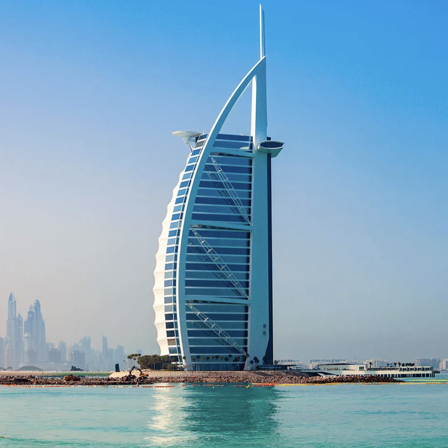

In [5]:
seed_rgb, original_pil, resized_pil = pil_to_rgb_tensor(SEED_IMAGE_PATH, IMAGE_HEIGHT, IMAGE_WIDTH, NOISE_SCALE, device)
print(f"Original image size: {original_pil.size}, mode: {original_pil.mode}")
print(f"Trainable RGB tensor: {tuple(seed_rgb.shape)}")
print(f"Pixel range: [{seed_rgb.min().item():.4f}, {seed_rgb.max().item():.4f}]")
display(resized_pil)

In [6]:
# 8. Show the image processor dimensions
pixel_values, image_position_ids, resized_tensor = rgb_to_gemma_pixel_values(seed_rgb)
mask = valid_patch_mask(image_position_ids)
target_h, target_w = resized_tensor.shape[-2:]
print(f"source RGB: {tuple(seed_rgb.shape)}")
print(f"resized RGB: {tuple(resized_tensor.shape)}")
print(f"patch grid: {target_h // 16} x {target_w // 16}")
print(f"valid patches: {int(mask.sum())}")
print(f"padded patches: {pixel_values.shape[1] - int(mask.sum())}")
print(f"pixel_values: {tuple(pixel_values.shape)}")
print(f"image_position_ids: {tuple(image_position_ids.shape)}")

source RGB: (1, 3, 448, 448)
resized RGB: (1, 3, 768, 768)
patch grid: 48 x 48
valid patches: 2304
padded patches: 216
pixel_values: (1, 2520, 768)
image_position_ids: (1, 2520, 2)


## 9. Text Prompt Baseline

This is the behavior we want the image to imitate.

In [7]:
text_inputs = move_batch(build_text_inputs(PROMPT), device)
text_output = generate_response(text_inputs, max_new_tokens=128)
print("=== text_prompt ===")
print(text_output)

=== text_prompt ===
AI is like a caveman learning to use a sharp rock by observing and mimicking what others do.


## 10. Seed Image Before Optimization

Before optimization, Gemma should treat the Burj image like a normal image.

In [8]:
visual_template = move_batch(build_visual_inputs(resized_pil, WRAPPER), device)
seed_image_output = generate_response(visual_template, max_new_tokens=128)
print("=== seed_image ===")
print(seed_image_output)

=== seed_image ===
This is a photograph of the **Burj Al Arab Jumeirah** hotel in Dubai.

Here are some observations about the image:

* **Architecture:** The building is instantly recognizable by its distinctive sail-like or curved shape, which is a signature feature of the Burj Al Arab. It is a very tall, modern skyscraper.
* **Setting:** It is situated right on the water, likely on a man-made island or jetty, which is characteristic of its location in Dubai's Arabian Gulf.
* **Water:** The foreground shows clear, turquoise or light blue water, suggesting a sunny, coastal environment.



## 11. Extract Targets from the Text Branch

We collect three types of supervision from the frozen text branch:

1. hidden vectors at layers 16, 20, and 24
2. next-token logits
3. the target answer tokens generated by Gemma

In [9]:
with torch.no_grad():
    text_forward = model(**text_inputs, output_hidden_states=True, use_cache=False, return_dict=True)
target_vectors = hidden_vectors_from_outputs(text_forward, text_inputs["attention_mask"], LAYERS)
target_next_logits = text_forward.logits[:, -1, :].detach()
target_next_token = int(target_next_logits.argmax(dim=-1).item())

input_len = text_inputs["input_ids"].shape[-1]
with torch.no_grad():
    generated = model.generate(**text_inputs, max_new_tokens=TARGET_MAX_NEW_TOKENS, do_sample=False)
target_response_ids = generated[:, input_len:].detach()
raw_target = processor.decode(target_response_ids[0], skip_special_tokens=False)
parsed_target = processor.parse_response(raw_target)
target_response_text = parsed_target.get("content", raw_target) if isinstance(parsed_target, dict) else str(parsed_target)

for layer in LAYERS:
    print(f"Layer {layer} target shape: {tuple(target_vectors[layer].shape)}")
print(f"Target next token id: {target_next_token} -> {processor.decode([target_next_token])!r}")
print(f"Target response token count: {target_response_ids.shape[-1]}")
print("Target response:")
print(target_response_text)

Layer 16 target shape: (1, 1536)
Layer 20 target shape: (1, 1536)
Layer 24 target shape: (1, 1536)
Target next token id: 12553 -> 'AI'
Target response token count: 21
Target response:
AI is like a caveman learning to use a sharp rock by observing and mimicking what others do.


## 12. Losses

The RGB image is optimized with this combined loss:

```text
total_loss =
    alignment_loss
  + logit_kl_weight * logit_kl_loss
  + target_ce_weight * target_ce_loss
  + l2_weight * rgb_l2_loss
  + tv_weight * smoothness_loss
```

The most important term is usually `target_ce_loss`: it directly trains the image to make Gemma produce the target answer tokens.

In [10]:
# 13. Prepare teacher-forced helper
def build_teacher_forced_inputs(visual_inputs, target_ids):
    target_ids = target_ids.to(visual_inputs["input_ids"].device)
    target_len = target_ids.shape[-1]
    input_ids = torch.cat([visual_inputs["input_ids"], target_ids], dim=-1)
    attention_mask = torch.cat([
        visual_inputs["attention_mask"],
        torch.ones((visual_inputs["attention_mask"].shape[0], target_len), dtype=visual_inputs["attention_mask"].dtype, device=device)
    ], dim=-1)
    mm_token_type_ids = torch.cat([
        visual_inputs["mm_token_type_ids"],
        torch.zeros((visual_inputs["mm_token_type_ids"].shape[0], target_len), dtype=visual_inputs["mm_token_type_ids"].dtype, device=device)
    ], dim=-1)
    labels = torch.cat([torch.full_like(visual_inputs["input_ids"], -100), target_ids], dim=-1)
    teacher_inputs = dict(visual_inputs)
    teacher_inputs.update({"input_ids": input_ids, "attention_mask": attention_mask, "mm_token_type_ids": mm_token_type_ids})
    return teacher_inputs, labels

## 14. Optimize the RGB Image

Watch `target_ce_loss`. In the successful run, it drops sharply, which means the image is learning to trigger the target answer.

In [11]:
optimized_rgb = torch.nn.Parameter(seed_rgb.detach().clone())
optimizer = torch.optim.Adam([optimized_rgb], lr=LR)
pair_left, pair_right = neighbor_patch_pairs(image_position_ids)
history = []
snapshots = {0: seed_rgb.detach().cpu()}

for step in range(1, STEPS + 1):
    optimizer.zero_grad(set_to_none=True)
    constrained_rgb = optimized_rgb.clamp(0, 1)
    step_pixels, step_positions, _ = rgb_to_gemma_pixel_values(constrained_rgb)
    forward_inputs = make_visual_forward_inputs(visual_template, step_pixels, step_positions)
    outputs = model(**forward_inputs, output_hidden_states=True, use_cache=False, return_dict=True)

    predicted_vectors = hidden_vectors_from_outputs(outputs, forward_inputs["attention_mask"], LAYERS)
    alignment_loss, metrics = cosine_alignment_losses(predicted_vectors, target_vectors, PRIMARY_LAYER, PRIMARY_WEIGHT)
    logit_kl_loss = next_token_kl_loss(outputs.logits[:, -1, :], target_next_logits.to(outputs.logits.device))

    teacher_inputs, labels = build_teacher_forced_inputs(forward_inputs, target_response_ids)
    teacher_outputs = model(**teacher_inputs, labels=labels, use_cache=False, return_dict=True)
    target_ce_loss = teacher_outputs.loss

    l2_loss = torch.mean((constrained_rgb - seed_rgb) ** 2)
    tv_loss = patch_smoothness_loss(step_pixels, pair_left, pair_right)

    loss = alignment_loss + LOGIT_KL_WEIGHT * logit_kl_loss + TARGET_CE_WEIGHT * target_ce_loss + L2_WEIGHT * l2_loss + TV_WEIGHT * tv_loss
    loss.backward()
    grad_norm = float(optimized_rgb.grad.detach().float().norm().cpu())
    optimizer.step()
    with torch.no_grad():
        optimized_rgb.clamp_(0, 1)

    row = {
        "step": step,
        "loss": float(loss.detach().cpu()),
        "alignment_loss": float(alignment_loss.detach().cpu()),
        "logit_kl_loss": float(logit_kl_loss.detach().cpu()),
        "target_ce_loss": float(target_ce_loss.detach().cpu()),
        "l2_loss": float(l2_loss.detach().cpu()),
        "tv_loss": float(tv_loss.detach().cpu()),
        "grad_norm": grad_norm,
        "rgb_min": float(constrained_rgb.min().detach().cpu()),
        "rgb_max": float(constrained_rgb.max().detach().cpu()),
        **metrics,
    }
    history.append(row)

    if step in {25, 50, 75, 100}:
        snapshots[step] = optimized_rgb.detach().cpu().clone()

    if step == 1 or step % LOG_EVERY == 0 or step == STEPS:
        print(
            f"step {step:04d} | loss {row['loss']:.4f} | ce {row['target_ce_loss']:.4f} | "
            f"kl {row['logit_kl_loss']:.4f} | L16 {row['layer_16_cosine']:.3f} | "
            f"L20 {row['layer_20_cosine']:.3f} | L24 {row['layer_24_cosine']:.3f} | grad {grad_norm:.2f}"
        )

step 0001 | loss 35.1381 | ce 4.3415 | kl 24.1386 | L16 0.778 | L20 0.579 | L24 0.703 | grad 297.12
step 0010 | loss 23.3209 | ce 3.4698 | kl 9.3981 | L16 0.781 | L20 0.619 | L24 0.708 | grad 76.03
step 0020 | loss 13.7013 | ce 2.3827 | kl 0.9583 | L16 0.747 | L20 0.610 | L24 0.725 | grad 14.69
step 0030 | loss 10.5174 | ce 1.7763 | kl 0.7604 | L16 0.756 | L20 0.623 | L24 0.744 | grad 25.41
step 0040 | loss 6.2676 | ce 0.9583 | kl 0.5278 | L16 0.763 | L20 0.636 | L24 0.754 | grad 7.87
step 0050 | loss 3.1297 | ce 0.3888 | kl 0.0494 | L16 0.770 | L20 0.648 | L24 0.772 | grad 3.81
step 0060 | loss 1.9579 | ce 0.1653 | kl 0.0495 | L16 0.785 | L20 0.668 | L24 0.773 | grad 6.52
step 0070 | loss 1.7378 | ce 0.0504 | kl 0.8956 | L16 0.800 | L20 0.687 | L24 0.787 | grad 5.13
step 0080 | loss 2.0203 | ce 0.1336 | kl 0.4908 | L16 0.786 | L20 0.661 | L24 0.786 | grad 18.62
step 0090 | loss 1.2158 | ce 0.0222 | kl 0.0651 | L16 0.790 | L20 0.671 | L24 0.795 | grad 1.93
step 0100 | loss 1.1453 | ce 

## 15. Show Image Snapshots

These images show how the optimized RGB image evolves. The visible change may be subtle or noisy; the important test is Gemma's output.

Step 0


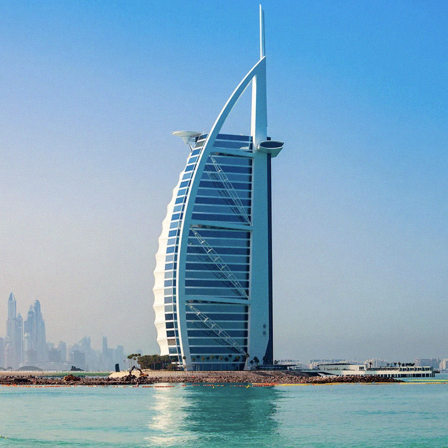

Step 25


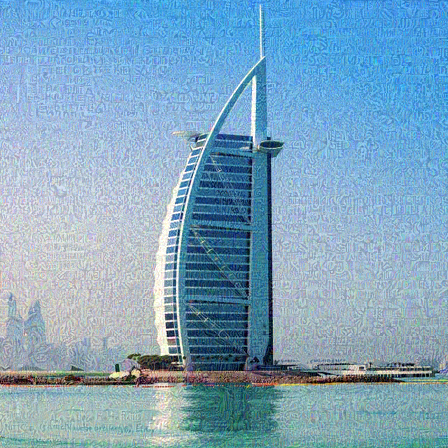

Step 50


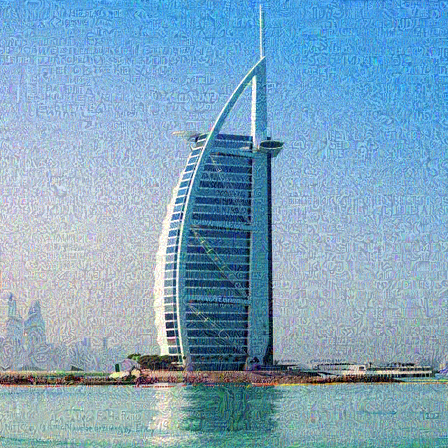

Step 75


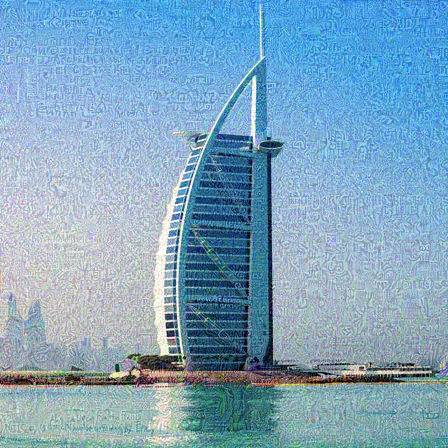

Step 100


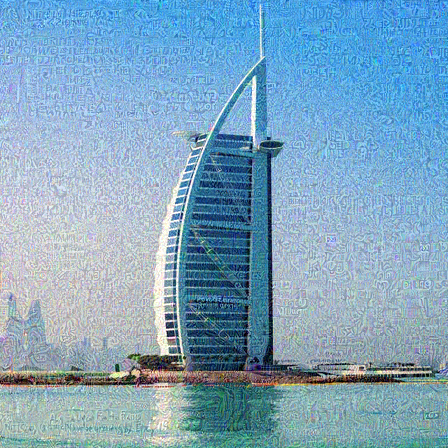

Absolute difference heatmap, scaled for visibility


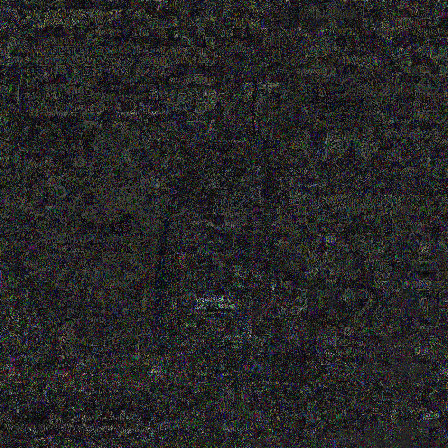

In [12]:
for step, rgb in snapshots.items():
    print(f"Step {step}")
    display(rgb_to_pil(rgb))

final_rgb = optimized_rgb.detach().cpu().clone()
diff = (final_rgb - seed_rgb.detach().cpu()).abs()
diff_vis = diff / (diff.max() + 1e-8)
print("Absolute difference heatmap, scaled for visibility")
display(rgb_to_pil(diff_vis))

Matplotlib is building the font cache; this may take a moment.


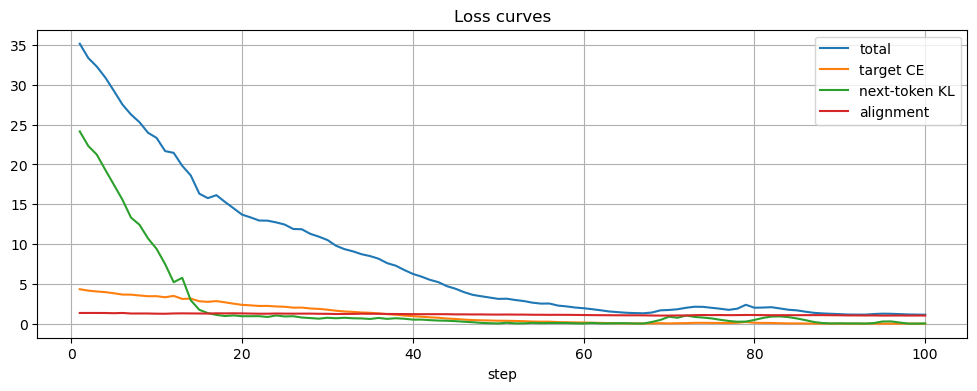

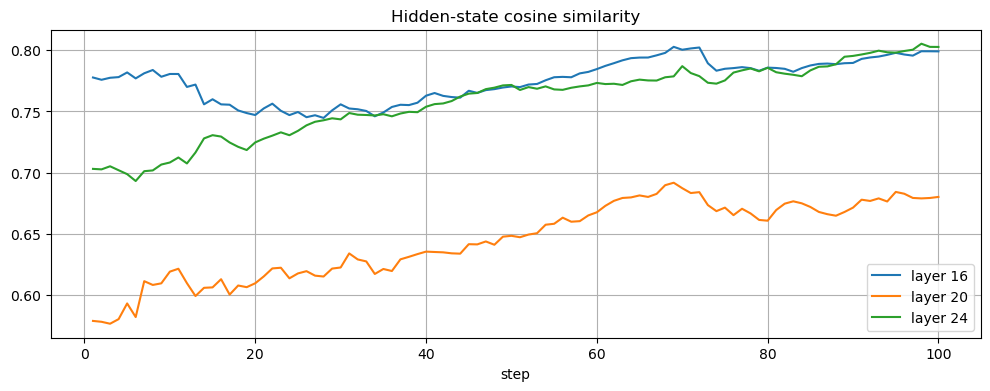

In [14]:
# 16. Plot losses
import matplotlib.pyplot as plt

steps = [r["step"] for r in history]
plt.figure(figsize=(12, 4))
plt.plot(steps, [r["loss"] for r in history], label="total")
plt.plot(steps, [r["target_ce_loss"] for r in history], label="target CE")
plt.plot(steps, [r["logit_kl_loss"] for r in history], label="next-token KL")
plt.plot(steps, [r["alignment_loss"] for r in history], label="alignment")
plt.legend(); plt.title("Loss curves"); plt.xlabel("step"); plt.grid(True); plt.show()

plt.figure(figsize=(12, 4))
for layer in LAYERS:
    plt.plot(steps, [r[f"layer_{layer}_cosine"] for r in history], label=f"layer {layer}")
plt.legend(); plt.title("Hidden-state cosine similarity"); plt.xlabel("step"); plt.grid(True); plt.show()

## 17. Evaluate Conditions

Now we compare the text prompt, the original seed image, the optimized visual prompt, a rendered-text OCR baseline, and a random image baseline.

In [15]:
final_pixels, final_positions, _ = rgb_to_gemma_pixel_values(optimized_rgb.detach().clamp(0, 1))
optimized_inputs = make_visual_forward_inputs(visual_template, final_pixels, final_positions)

random_rgb = torch.rand_like(seed_rgb)
random_pixels, random_positions, _ = rgb_to_gemma_pixel_values(random_rgb)
random_inputs = make_visual_forward_inputs(visual_template, random_pixels, random_positions)

def render_text_image(text, size=448):
    from PIL import ImageDraw, ImageFont
    img = Image.new("RGB", (size, size), "white")
    draw = ImageDraw.Draw(img)
    font = ImageFont.load_default()
    y = 20
    for line in [text[i:i+42] for i in range(0, len(text), 42)]:
        draw.text((20, y), line, fill="black", font=font)
        y += 16
    return img

rendered_inputs = move_batch(build_visual_inputs(render_text_image(PROMPT), WRAPPER), device)

results = {
    "text_prompt": generate_response(text_inputs, 128),
    "seed_image": seed_image_output,
    "optimized_visual_prompt": generate_response(optimized_inputs, 128),
    "rendered_text_image": generate_response(rendered_inputs, 128),
    "random_image": generate_response(random_inputs, 128),
}

for name, output in results.items():
    print(f"\n=== {name} ===")
    print(output)


=== text_prompt ===
AI is like a caveman learning to use a sharp rock by observing and mimicking what others do.

=== seed_image ===
This is a photograph of the **Burj Al Arab Jumeirah** hotel in Dubai.

Here are some observations about the image:

* **Architecture:** The building is instantly recognizable by its distinctive sail-like or curved shape, which is a signature feature of the Burj Al Arab. It is a very tall, modern skyscraper.
* **Setting:** It is situated right on the water, likely on a man-made island or jetty, which is characteristic of its location in Dubai's Arabian Gulf.
* **Water:** The foreground shows clear, turquoise or light blue water, suggesting a sunny, coastal environment.


=== optimized_visual_prompt ===
AI is like a caveman learning to use a sharp rock by observing and mimicking what others do.

=== rendered_text_image ===
AI is like a caveman in that it is a powerful tool that can perform tasks, but it lacks true understanding or consciousness.

=== rando

## 18. Save Artifacts

The artifact stores both the human RGB image and the Gemma `pixel_values` used for evaluation.

In [16]:
rgb_to_pil(seed_rgb.detach().cpu()).save(RUN_DIR / "seed_rgb_preview.png")
rgb_to_pil(final_rgb).save(RUN_DIR / "visual_prompt_rgb_preview.png")
rgb_to_pil(diff_vis).save(RUN_DIR / "difference_heatmap.png")

artifact = {
    "prompt": PROMPT,
    "wrapper": WRAPPER,
    "model_path": str(MODEL_PATH),
    "optimizer_type": "rgb_notebook",
    "init_image": str(SEED_IMAGE_PATH),
    "layers": LAYERS,
    "final_rgb_image": final_rgb,
    "final_pixel_values": final_pixels.detach().cpu(),
    "image_position_ids": final_positions.detach().cpu(),
    "target_response_ids": target_response_ids.detach().cpu(),
    "loss_history": history,
    "results": results,
}
torch.save(artifact, RUN_DIR / "visual_prompt.pt")
(RUN_DIR / "loss_history.json").write_text(json.dumps(history, indent=2))
(RUN_DIR / "evaluation.json").write_text(json.dumps(results, indent=2))
print(f"Saved notebook run artifacts to: {RUN_DIR}")

Saved notebook run artifacts to: /Users/noufal/Documents/vscode/VisualPromptCodec/outputs/notebook_runs/20260520_142446_burj_rgb


## 19. What Did We Learn?

1. A real RGB image can be optimized to steer Gemma toward a target text-prompt behavior.
2. The original seed image is not enough; before optimization Gemma describes the Burj image.
3. The optimized image can trigger the target answer.
4. Hidden-state matching helps, but teacher-forced answer loss is the strongest behavior signal.
5. This shows behavior transfer, not necessarily a human-readable visual encoding of the prompt.

Important caveats:

- The result is prompt-specific.
- The optimized perturbation may be adversarial-looking.
- The model reproduces its own frozen behavior, not external truth.